In [1]:
import os, datetime, sys, time, traceback

import pandas as pd
import numpy as np
import pickle as pkl
import multiprocessing as mp
import matplotlib.pyplot as plt

from itertools import product
from mpi4py import MPI

from skfda.exploratory.depth import ModifiedBandDepth
from functional_utils import _confidence_bands_from_eCDF

from ffc_utils import (_fknn_forecast_dynamic_update,
                       _functional_downsampling, 
                       _focal_curve_envelope, 
                       _functional_confidence_band)


from scores_utils import (_empirical_coverage_score,
                          _empirical_interval_score)

path_to_fDepth     = '/home/gterren/dynamic_update/functional_forecast_dynamic_update/fDepth'
path_to_data       = '/home/gterren/dynamic_update/data'
path_to_validation = '/home/gterren/dynamic_update/validation'
path_to_param      = '/home/gterren/dynamic_update/params'
path_to_test       = '/home/gterren/dynamic_update/test'

In [2]:
# Calibration experiments setup
resource = 'wind'
method   = 'fusion'

T = 288
# Load 2017 data as training set
with open(path_to_data + f"/linear_preprocessed_{resource}_2017.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_tr_ = _data["assets"]
F_tr_      = _data["observations"]
E_tr_      = _data["forecasts"]
#print(assets_tr_.shape, F_tr_.shape, E_tr_.shape)

# Reshape to day x interval x asset format
F_tr_ = F_tr_.reshape(int(F_tr_.shape[0]/T), T, F_tr_.shape[1])
E_tr_ = E_tr_.reshape(int(E_tr_.shape[0]/T), T, E_tr_.shape[1])
#print(F_tr_.shape, E_tr_.shape)

# Load 2018 data as testing set
with open(path_to_data + f"/linear_preprocessed_{resource}_2018.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_ts_ = _data["assets"]
F_ts_      = _data["observations"]
E_ts_      = _data["forecasts"]
#print(assets_ts_.shape, F_ts_.shape, E_ts_.shape)

# Reshape to day x interval x asset format
F_ts_ = F_ts_.reshape(int(F_ts_.shape[0]/T), T, F_ts_.shape[1])
E_ts_ = E_ts_.reshape(int(E_ts_.shape[0]/T), T, E_ts_.shape[1])
#print(F_ts_.shape, E_ts_.shape)

# Short testing set with training set order
order  = {v: i for i, v in enumerate(assets_tr_)}
idx_   = np.argsort([order[x] for x in assets_ts_])
F_ts_  = F_ts_[:, :, idx_]
E_ts_  = E_ts_[:, :, idx_]
#print(F_ts_.shape, E_ts_.shape)

# From generation to capacity factor
p_tr_ = np.max(np.max(F_tr_, axis = 0), axis = 0)
p_ts_ = np.max(np.max(F_ts_, axis = 0), axis = 0)
# print(p_tr_.shape, p_ts_.shape)

E_tr_ /= np.tile(p_tr_, (E_tr_.shape[0], E_tr_.shape[1], 1))
E_ts_ /= np.tile(p_ts_, (E_ts_.shape[0], E_ts_.shape[1], 1))
# print(E_tr_.min(), E_tr_.max())
# print(E_ts_.min(), E_ts_.max())

# No possible a capacity factor is larger than 1 or smaller than 0
E_tr_[E_tr_ > 1.] = 1.
E_tr_[E_tr_ < 0.] = 0.
E_ts_[E_ts_ > 1.] = 1.
E_ts_[E_ts_ < 0.] = 0.

# Format training set from day x interval x asset to [day * asset] x interval
E_ts_lin_ = E_ts_.copy()
E_tr_lin_ = np.concatenate([E_tr_[..., k] 
                            for k in range(E_tr_.shape[2])], axis = 0)
#print(E_tr_lin_.shape, E_ts_lin_.shape)

# Load 2017 data as training set
with open(path_to_data + f"/preprocessed_{resource}_2017.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_tr_ = _data["assets"]
x_tr_      = _data["locations"]
dates_tr_  = _data["dates"]
F_tr_      = _data["observations"]
E_tr_      = _data["forecasts"]
#print(assets_tr_.shape, x_tr_.shape, dates_tr_.shape, F_tr_.shape, E_tr_.shape)

# Reshape to day x interval x asset format
F_tr_ = F_tr_.reshape(int(F_tr_.shape[0]/T), T, F_tr_.shape[1])
E_tr_ = E_tr_.reshape(int(E_tr_.shape[0]/T), T, E_tr_.shape[1])
T_tr_ = dates_tr_.reshape(int(dates_tr_.shape[0]/T), T)
#print(F_tr_.shape, E_tr_.shape, T_tr_.shape)

# Load 2018 data as testing set
with open(path_to_data + f"/preprocessed_{resource}_2018.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_ts_ = _data["assets"]
x_ts_      = _data["locations"]
dates_ts_  = _data["dates"]
F_ts_      = _data["observations"]
E_ts_      = _data["forecasts"]
#print(assets_ts_.shape, x_ts_.shape, dates_ts_.shape, F_ts_.shape, E_ts_.shape)

# Reshape to day x interval x asset format
F_ts_ = F_ts_.reshape(int(F_ts_.shape[0]/T), T, F_ts_.shape[1])
E_ts_ = E_ts_.reshape(int(E_ts_.shape[0]/T), T, E_ts_.shape[1])
T_ts_ = dates_ts_.reshape(int(dates_ts_.shape[0]/T), T)
#print(F_ts_.shape, E_ts_.shape, T_ts_.shape)

dt_ = np.array([t * 5 for t in range(T)])
dx_ = pd.to_datetime(pd.DataFrame({"time": dt_}).time, unit = "m").dt.strftime("%H:%M").to_numpy()
#print(dt_.shape, dx_.shape)

# Short testing set with training set order
order      = {v: i for i, v in enumerate(assets_tr_)}
idx_       = np.argsort([order[x] for x in assets_ts_])
assets_ts_ = assets_ts_[idx_]
x_ts_      = x_ts_[idx_]
F_ts_      = F_ts_[:, :, idx_]
E_ts_      = E_ts_[:, :, idx_]
#print(F_ts_.shape, E_ts_.shape, T_ts_.shape)

# From generation to capacity factor
p_tr_ = np.max(np.max(F_tr_, axis = 0), axis = 0)
p_ts_ = np.max(np.max(F_ts_, axis = 0), axis = 0)
#print(p_tr_.shape, p_ts_.shape)

F_tr_ /= np.tile(p_tr_, (F_tr_.shape[0], F_tr_.shape[1], 1))
E_tr_ /= np.tile(p_tr_, (E_tr_.shape[0], E_tr_.shape[1], 1))
F_ts_ /= np.tile(p_ts_, (F_ts_.shape[0], F_ts_.shape[1], 1))
E_ts_ /= np.tile(p_ts_, (E_ts_.shape[0], E_ts_.shape[1], 1))
# print(F_tr_.min(), F_tr_.max())
# print(E_tr_.min(), E_tr_.max())
# print(F_ts_.min(), F_ts_.max())
# print(E_ts_.min(), E_ts_.max())

# No possible a capacity factor is larger than 1 or smaller than 0
F_tr_[F_tr_ > 1.] = 1.
F_tr_[F_tr_ < 0.] = 0.
F_ts_[F_ts_ > 1.] = 1.
F_ts_[F_ts_ < 0.] = 0.
E_tr_[E_tr_ > 1.] = 1.
E_tr_[E_tr_ < 0.] = 0.
E_ts_[E_ts_ > 1.] = 1.
E_ts_[E_ts_ < 0.] = 0.

# Format training set from day x interval x asset to [day * asset] x interval
T_tr_ = np.concatenate([T_tr_ for k in range(assets_tr_.shape[0])], axis = 0)
assets_tr_ = np.concatenate([np.tile(assets_tr_[k], (F_tr_.shape[0], 1)) for k in range(assets_tr_.shape[0])], axis = 0)
x_tr_ = np.concatenate([np.tile(x_tr_[k, :], (F_tr_.shape[0], 1)) for k in range(x_tr_.shape[0])], axis = 0)
F_tr_ = np.concatenate([F_tr_[..., k] for k in range(F_tr_.shape[2])], axis = 0)
E_tr_ = np.concatenate([E_tr_[..., k] for k in range(E_tr_.shape[2])], axis = 0)
#print(x_tr_.shape, assets_tr_.shape, F_tr_.shape, E_tr_.shape, T_tr_.shape)
#print(x_ts_.shape, assets_ts_.shape, F_ts_.shape, E_ts_.shape, T_ts_.shape)

t_tr_ = np.array([datetime.datetime.strptime(t_tr, "%Y-%m-%d %H:%M:%S").timetuple().tm_yday for t_tr in T_tr_[:, 0]]) - 1
t_ts_ = np.array([datetime.datetime.strptime(t_ts, "%Y-%m-%d %H:%M:%S").timetuple().tm_yday for t_ts in T_ts_[:, 0]]) - 1
#print(t_tr_.shape, t_ts_.shape)

                     72        144       216
parameter                                   
forget_rate_f     0.0625    0.0625    0.0625
forget_rate_e     2.0000    2.0000    2.0000
lookup_rate     256.0000  256.0000  512.0000
length_scale_f    0.0500    0.0500    0.0250
length_scale_e    0.1000    0.1000    0.1000
trust_rate        0.1000    0.1000    0.1000
nu                1.0000    2.0000    3.0000
xi                0.9000    0.9000    0.9000
gamma            90.0000   70.0000   70.0000
kappa_min       100.0000  100.0000  100.0000
kappa_max       100.0000  100.0000  100.0000


(363, 216) (363, 216) (363, 216) (363, 216)


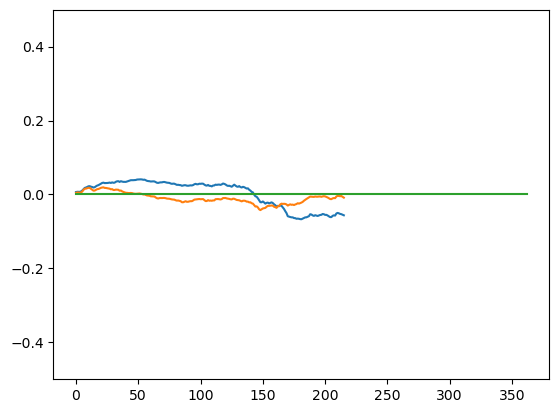

(363, 216) (363, 216) (363, 216) (363, 216)


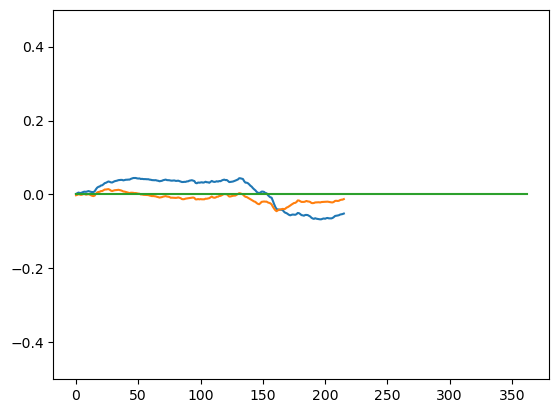

(363, 216) (363, 216) (363, 216) (363, 216)


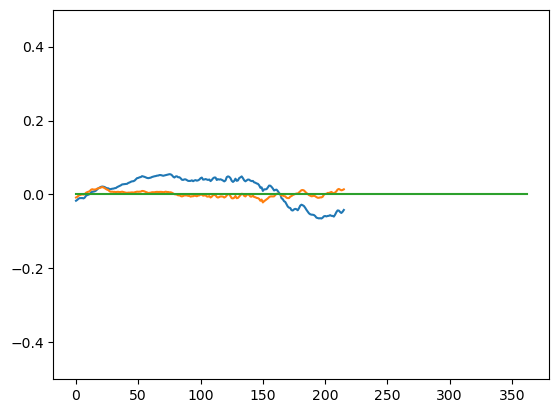

(363, 216) (363, 216) (363, 216) (363, 216)


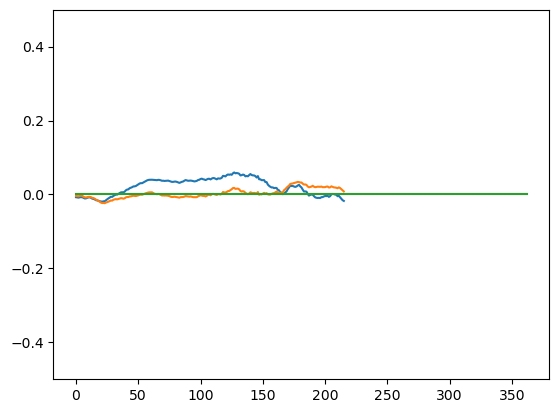

(363, 216) (363, 216) (363, 216) (363, 216)


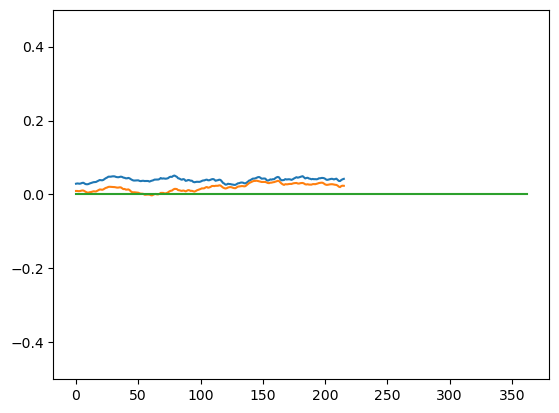

In [ ]:
time = 72

# Validation set identifier
hyper_         = pd.read_csv(path_to_param + f'/{resource}-{method}-params_iter_1.csv')
hyper_         = hyper_.set_index("parameter")
hyper_.columns = hyper_.columns.astype(int)
print(hyper_)

def _run_parallel(day):

    file_name = f'{asset}-{day}-{time}'

    # Get functional predictors for a given test
    f_     = F_ts_[day, :time, asset]
    e_lin_ = E_ts_lin_[day, :, asset]
    e_     = E_ts_[day, :, asset]
    x_     = x_ts_[asset, :]
    t      = t_ts_[day]
    f_hat_ = F_ts_[day, time:, asset]

    bias_  = F_ts_[day, time:, asset] - E_ts_[day, time:, asset]

    # Filter solar hours with loading solar set
    idx_days_  = np.absolute(t_tr_ - day) < 7
    idx_hours_ = (np.sum(F_tr_[idx_days_, :], axis = 0) 
            + np.sum(E_tr_[idx_days_, :], axis = 0)) > 1.

    _meta, M_ = _fknn_forecast_dynamic_update(F_tr_, E_tr_lin_, x_tr_, t_tr_, dt_, f_, e_lin_, x_, t,
                                              forget_rate_f  = hyper_.loc['forget_rate_f'][time],
                                              forget_rate_e  = hyper_.loc['forget_rate_e'][time],
                                              length_scale_f = hyper_.loc['length_scale_f'][time],
                                              length_scale_e = hyper_.loc['length_scale_e'][time],
                                              lookup_rate    = hyper_.loc['lookup_rate'][time],
                                              #trust_rate     = hyper_.loc['trust_rate'][time],
                                              trust_rate     = 0.1,
                                              nu             = hyper_.loc['nu'][time],
                                              gamma          = 80.,
                                              xi             = 0.25,
                                              kappa_min      = hyper_.loc['kappa_min'][time],
                                              kappa_max      = hyper_.loc['kappa_max'][time], 
                                              idx_hours_     = idx_hours_)

    return [np.median(M_, axis = 0), f_hat_, _meta['focal_curve'], bias_]


n_workers = 36

for asset in [20, 21, 22, 23, 25]:
    with mp.Pool(processes = n_workers) as pool:
        indices_ = range(363)
        results_ = pool.map(_run_parallel, indices_)

    med_   = np.stack([result[0] for result in results_])
    f_hat_ = np.stack([result[1] for result in results_])
    focal_ = np.stack([result[2] for result in results_])
    bias_  = np.stack([result[3] for result in results_])

    print(med_.shape, f_hat_.shape, focal_.shape, bias_.shape)

    plt.figure()
    plt.plot(np.mean(f_hat_ - med_, axis=0))
    plt.plot(np.mean(f_hat_ - focal_, axis=0))
    plt.plot(np.zeros((bias_.shape[1]),))
    plt.ylim(-0.5, 0.5)

    plt.show()